# Лабораторная работа № 4

## Бинарная классификация сбалансированного и несбалансированного набора данных

**Цель работы:** изучение принципов решения задачи классификации с использованием методов машинного обучения.

Проанализируем набор данных `employees_4.csv`. Набор данных содержит информацию о сотрудниках компании, включая их образование, историю работы, демографию и факторы, связанные с занятостью.

Признаки:
- **Education** – образовательная квалификация сотрудника (Bachelors, Masters, PHD)
- **JoiningYear** – год, когда сотрудник присоединился к компании
- **City** – город, где работает сотрудник (Bangalore, Pune, New Delhi)
- **PaymentTier** – уровень оплаты труда (1, 2, 3)
- **Age** – возраст сотрудника
- **Gender** – пол сотрудника
- **EverBenched** – находился ли сотрудник когда-либо временно без назначенной работы (No/Yes)
- **ExperienceInCurrentDomain** – количество лет работы сотрудника в текущей сфере
- **LeaveOrNot** – целевая переменная: уволился сотрудник или нет (0 – нет, 1 – да)

## 0. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

%matplotlib inline
sns.set_style("whitegrid")

## 1. Загрузка набора данных как датафрейма библиотеки pandas

In [2]:
df = pd.read_csv('employees_4.csv')
print("Размер датафрейма:", df.shape)
df.head()

Размер датафрейма: (4653, 9)


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


## 2. Общее представление о наборе данных: shape, head, describe, info

In [3]:
df.shape

(4653, 9)

In [4]:
df.head(10)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


In [5]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


## 3. Проверка сбалансированности набора данных

Целевая переменная – `LeaveOrNot`. Проверим соотношение классов.

In [7]:
df['LeaveOrNot'].value_counts()

LeaveOrNot
0    3053
1    1600
Name: count, dtype: int64

In [8]:
df['LeaveOrNot'].value_counts(normalize=True) * 100

LeaveOrNot
0    65.613583
1    34.386417
Name: proportion, dtype: float64

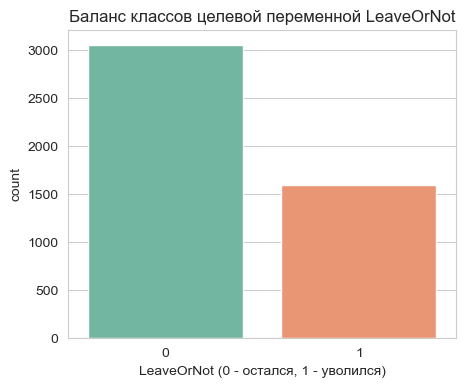

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='LeaveOrNot', hue='LeaveOrNot', palette='Set2', legend=False)
plt.title('Баланс классов целевой переменной LeaveOrNot')
plt.xlabel('LeaveOrNot (0 - остался, 1 - уволился)')
plt.show()

Набор данных умеренно несбалансирован: класс "0" (сотрудник остался) представлен несколько больше, чем класс "1" (сотрудник уволился), но дисбаланс не критичен (соотношение не превышает 2:1), поэтому специальных методов балансировки (SMOTE, undersampling) можно не применять, но при интерпретации метрик нужно учитывать этот факт (использовать не только accuracy, но и precision/recall/f1).

## 4. Анализ влияния признаков на класс

Построим графики зависимости целевой переменной от различных признаков и матрицу корреляции, чтобы оценить влияние признаков и определить, есть ли несущественные признаки, которые можно удалить.

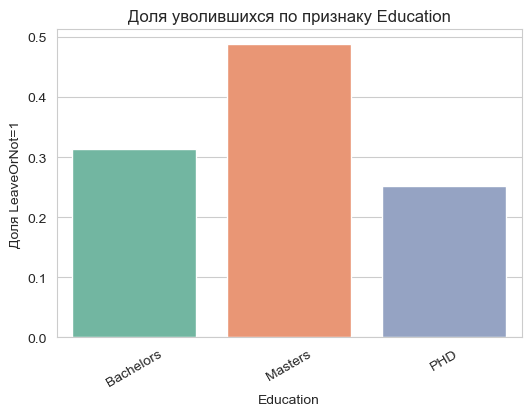

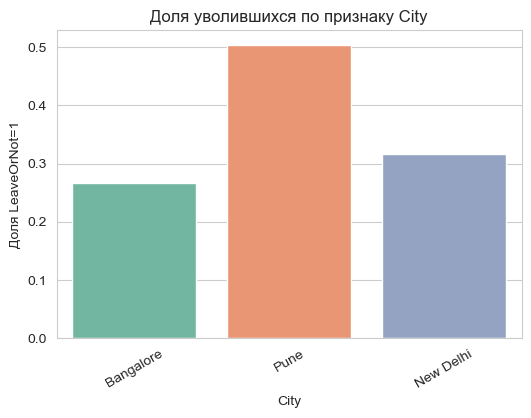

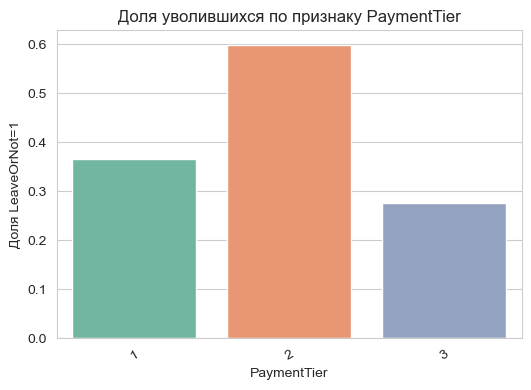

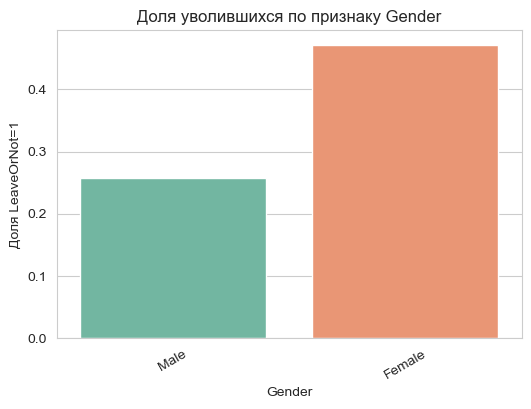

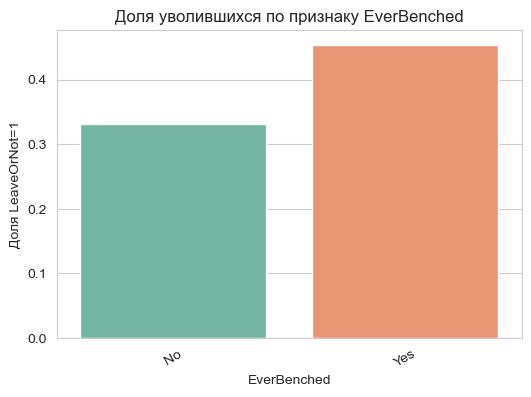

In [10]:
for col in ['Education', 'City', 'PaymentTier', 'Gender', 'EverBenched']:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x=col, y='LeaveOrNot', hue=col, palette='Set2', legend=False, errorbar=None)
    plt.title(f'Доля уволившихся по признаку {col}')
    plt.ylabel('Доля LeaveOrNot=1')
    plt.xticks(rotation=30)
    plt.show()

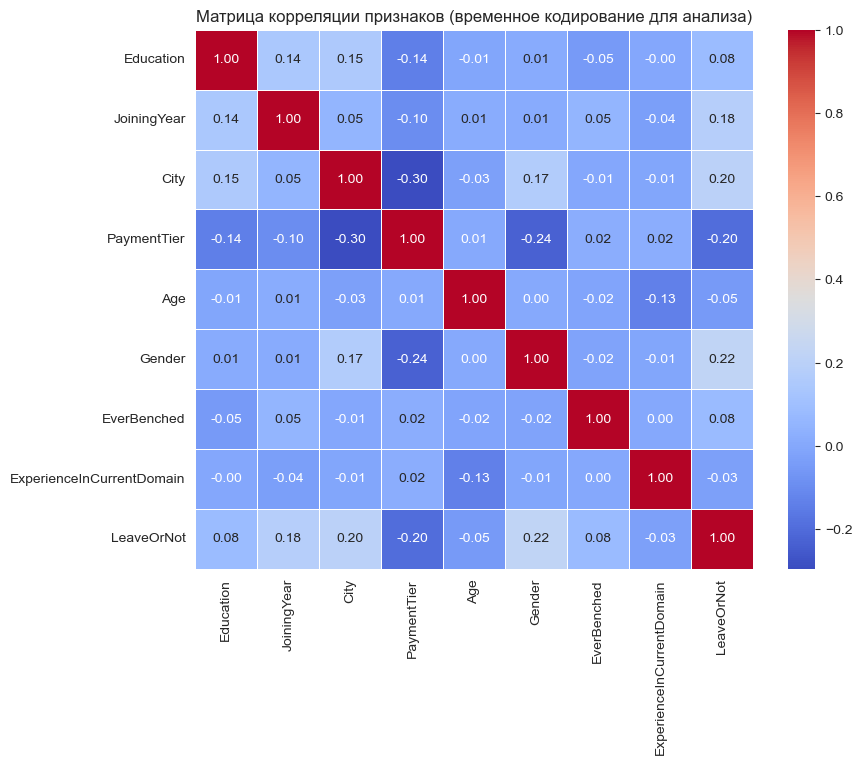

In [11]:
numeric_df = df.copy()
numeric_df['Gender'] = numeric_df['Gender'].map({'Male': 0, 'Female': 1})
numeric_df['EverBenched'] = numeric_df['EverBenched'].map({'No': 0, 'Yes': 1})
numeric_df['Education'] = numeric_df['Education'].map({'Bachelors': 0, 'Masters': 1, 'PHD': 2})
numeric_df['City'] = LabelEncoder().fit_transform(numeric_df['City'])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков (временное кодирование для анализа)')
plt.show()

Из построенных графиков и матрицы корреляции видно, что наибольшее влияние на увольнение сотрудника (`LeaveOrNot`) оказывают признаки `JoiningYear`, `PaymentTier`, `City`, `EverBenched` и `Age`. Признак `Gender` также имеет заметное влияние. Явно несущественных признаков, которые следовало бы удалить из набора, не обнаружено – все признаки сохраняются для построения модели.

## 5. Предобработка данных

### 5.1. Проверка пропущенных значений

In [12]:
df.isna().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

Пропущенных значений в наборе данных нет, поэтому дополнительная обработка пропусков не требуется.

### 5.2. Кодирование категориальных признаков с помощью методов библиотеки sklearn

In [13]:
df_enc = df.copy()

# Бинарные категориальные признаки кодируем LabelEncoder
le_gender = LabelEncoder()
df_enc['Gender'] = le_gender.fit_transform(df_enc['Gender'])
print("Gender классы:", le_gender.classes_)

le_bench = LabelEncoder()
df_enc['EverBenched'] = le_bench.fit_transform(df_enc['EverBenched'])
print("EverBenched классы:", le_bench.classes_)

# Education и City - номинальные признаки с несколькими категориями - применим OneHot через pd.get_dummies
df_enc = pd.get_dummies(df_enc, columns=['Education', 'City'], drop_first=True)
df_enc.head()

Gender классы: ['Female' 'Male']
EverBenched классы: ['No' 'Yes']


,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune
0,2017,3,34,1,0,0,0,False,False,False,False
1,2013,1,28,0,0,3,1,False,False,False,True
2,2014,3,38,0,0,2,0,False,False,True,False
3,2016,3,27,1,0,5,1,True,False,False,False
4,2017,3,24,1,1,2,1,True,False,False,True


### 5.3. Нормализация данных с помощью методов библиотеки sklearn

In [14]:
feature_cols = [c for c in df_enc.columns if c != 'LeaveOrNot']
X = df_enc[feature_cols]
y = df_enc['LeaveOrNot']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
X_scaled.head()

,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,Education_Masters,Education_PHD,City_New Delhi,City_Pune
0,1.039638,0.537503,0.954645,0.821551,-0.338365,-1.864901,-0.480575,-0.200022,-0.575282,-0.612041
1,-1.107233,-3.025177,-0.288732,-1.217210,-0.338365,0.060554,-0.480575,-0.200022,-0.575282,1.633878
2,-0.570515,0.537503,1.783563,-1.217210,-0.338365,-0.581264,-0.480575,-0.200022,1.738277,-0.612041
3,0.502921,0.537503,-0.495961,0.821551,-0.338365,1.344191,2.080840,-0.200022,-0.575282,-0.612041
4,1.039638,0.537503,-1.117650,0.821551,2.955387,-0.581264,2.080840,-0.200022,-0.575282,1.633878


## 6. Разбиение обработанного набора данных на обучающую и тестовую выборки

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=0, stratify=y)
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (3489, 10)
Размер тестовой выборки: (1164, 10)


## 7. Обучение модели логистической регрессии (LogisticRegression) библиотеки sklearn

In [16]:
model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## 8. Оценка корректности модели на тестовой и обучающей выборках

Используем стандартные метрики библиотеки sklearn.

In [17]:
def print_metrics(y_true, y_pred, name):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print()

print_metrics(y_train, y_train_pred, "Обучающая выборка")
print_metrics(y_test, y_test_pred, "Тестовая выборка")

--- Обучающая выборка ---
Accuracy: 0.7391802808827744
Precision: 0.6912928759894459
Recall: 0.43666666666666665
F1-score: 0.5352400408580184

--- Тестовая выборка ---
Accuracy: 0.7259450171821306
Precision: 0.6653061224489796
Recall: 0.4075
F1-score: 0.5054263565891473



In [18]:
print("Отчёт по классификации (тестовая выборка):")
print(classification_report(y_test, y_test_pred))

Отчёт по классификации (тестовая выборка):
              precision    recall  f1-score   support

           0       0.74      0.89      0.81       764
           1       0.67      0.41      0.51       400

    accuracy                           0.73      1164
   macro avg       0.70      0.65      0.66      1164
weighted avg       0.72      0.73      0.71      1164



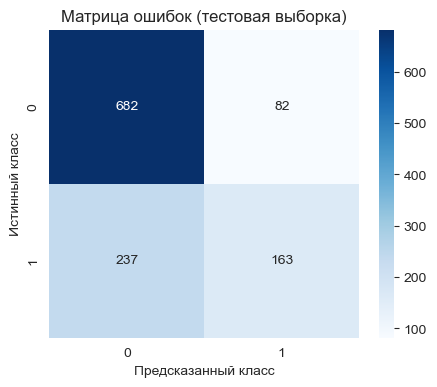

In [19]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (тестовая выборка)')
plt.show()

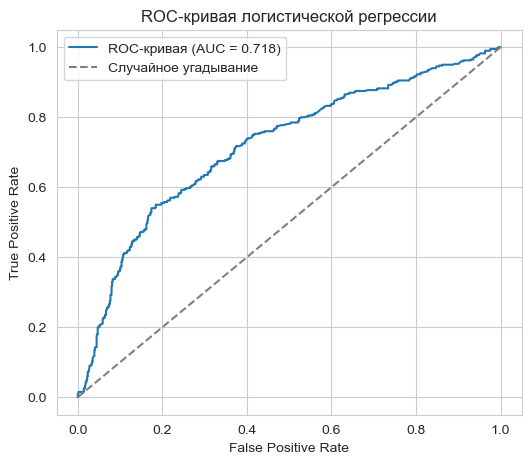

In [20]:
y_test_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Случайное угадывание')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая логистической регрессии')
plt.legend()
plt.show()

## Выводы

- Набор данных `employees_4.csv` умеренно несбалансирован по целевой переменной `LeaveOrNot`, но не требует специальной балансировки.
- Наибольшее влияние на увольнение сотрудника оказывают год трудоустройства, уровень оплаты труда, город и нахождение в резерве.
- После кодирования категориальных признаков и нормализации данные разбиты на обучающую (75%) и тестовую (25%) выборки.
- Обученная модель логистической регрессии показывает сопоставимые метрики качества на обучающей и тестовой выборках, что говорит об отсутствии значительного переобучения.
- Значение AUC ROC-кривой свидетельствует о способности модели отличать сотрудников, склонных к увольнению, от тех, кто останется в компании, лучше случайного угадывания.